## Multiple linear regression in finance + A trading strategy

Our goal is to create a predictive model that can forecast the next day's directional movement of the SPY ETF using global market indexes.

In [310]:
%%capture

%pip install numpy pandas matplotlib yfinance
%pip install --upgrade pip
%pip install statsmodels

In [311]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import yfinance as yf
from scipy.stats import norm, t, ttest_1samp
from pandas.plotting import autocorrelation_plot, scatter_matrix
from statsmodels.tsa.stattools import acf
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot

import warnings
warnings.filterwarnings("ignore")

In [312]:
# import all stock market data into DataFrame
aord = yf.download('^AORD', start='2000-01-01', end='2025-12-31')
nikkei = yf.download('^N225', start='2000-01-01', end='2025-12-31')
hsi = yf.download('^HSI', start='2000-01-01', end='2025-12-31')
daxi = yf.download('^GDAXI', start='2000-01-01', end='2025-12-31')
cac40 = yf.download('^FCHI', start='2000-01-01', end='2025-12-31')
sp500 = yf.download('^GSPC', start='2000-01-01', end='2025-12-31')
dji = yf.download('^DJI', start='2000-01-01', end='2025-12-31')
nasdaq = yf.download('^IXIC', start='2000-01-01', end='2025-12-31')
spy = yf.download('SPY', start='2000-01-01', end='2025-12-31')

# remove the 'Ticker' level from the column MultiIndex
aord.columns = aord.columns.droplevel('Ticker')
nikkei.columns = nikkei.columns.droplevel('Ticker')
hsi.columns = hsi.columns.droplevel('Ticker')
daxi.columns = daxi.columns.droplevel('Ticker')
cac40.columns = cac40.columns.droplevel('Ticker')
sp500.columns = sp500.columns.droplevel('Ticker')
dji.columns = dji.columns.droplevel('Ticker')
nasdaq.columns = nasdaq.columns.droplevel('Ticker')
spy.columns = spy.columns.droplevel('Ticker')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [313]:
spy.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,91.132820,92.895165,90.153740,92.895165,8164300
2000-01-04,87.568893,90.271154,87.500358,89.938266,8089800
2000-01-05,87.725563,88.685061,86.002382,87.686400,12177900
2000-01-06,86.315674,88.665465,86.315674,87.490570,6227200
2000-01-07,91.328560,91.328560,87.764710,87.921362,8066500


### Step 1: Data Munging

To handle the timezone differences, we extract and calculate appropriate stock market data for analysis. 
*Indicepanel* is the DataFrame of our trading model.

In [314]:
indicepanel=pd.DataFrame(index=spy.index)    # defining indicepanel dataframe, indexed by spy's dates

# US markets
indicepanel['spy']=spy['Open'].shift(-1)-spy['Open']    # price change in SPY across last day
indicepanel['spy_lag1']=indicepanel['spy'].shift(1)    
indicepanel['sp500']=sp500["Open"]-sp500['Open'].shift(1)    # price change in S&P500 across last day
indicepanel['nasdaq']=nasdaq['Open']-nasdaq['Open'].shift(1)    # price change in NASDAQ across last day
indicepanel['dji']=dji['Open']-dji['Open'].shift(1)    # price change in DJI across last day

# European markets
indicepanel['cac40']=cac40['Open']-cac40['Open'].shift(1)    # price change in CAC40 across last day
indicepanel['daxi']=daxi['Open']-daxi['Open'].shift(1)    # price change in DAXI across last day

# Asian markets
indicepanel['aord']=aord['Close']-aord['Open']    # close minus open of AORD
indicepanel['hsi']=hsi['Close']-hsi['Open']    # close minus open of HSI
indicepanel['nikkei']=nikkei['Close']-nikkei['Open']    # close minus open of NIKKEI

# response variable: SPY opening price for today
indicepanel['Price']=spy['Open']

In [315]:
indicepanel.head()

,spy,spy_lag1,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei,Price
Date,,,,,,,,,,,
2000-01-03,-2.956899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,311.931641,NaN,92.895165
2000-01-04,-2.251867,-2.956899,-14.030029,-166.189941,-152.099609,-102.149902,-214.479980,-28.399902,-230.179688,65.410156,89.938266
2000-01-05,-0.195830,-2.251867,-55.799927,-165.649902,-360.379883,-400.399902,-161.390137,-73.200195,-761.831055,-460.958984,87.686400
2000-01-06,0.430793,-0.195830,2.689941,-19.910156,124.000000,-35.899902,-84.399902,-20.799805,-788.839844,-405.740234,87.490570
2000-01-07,3.720476,0.430793,1.339966,-123.349854,133.689453,-62.050293,-11.510254,14.399902,76.290039,-0.640625,87.921362


We can check how many NaN values are in each column.

In [316]:
indicepanel.isnull().sum()

spy           1
spy_lag1      1
sp500         1
nasdaq        1
dji           1
cac40        70
daxi        110
aord        137
hsi         301
nikkei      386
Price         0
dtype: int64

We now replace NaN values with the preceding values, using the forward fill (ffill) method. This essentially reproduces the notion of the market holding steady during holidays.

After this, we also remove any remaining NaN values (which are basically those that are in the first row).

In [317]:
indicepanel = indicepanel.fillna(method='ffill')
indicepanel = indicepanel.dropna()

We can do a quick check to verify that there are no more NaN values.

In [318]:
indicepanel.isnull().sum()

spy         0
spy_lag1    0
sp500       0
nasdaq      0
dji         0
cac40       0
daxi        0
aord        0
hsi         0
nikkei      0
Price       0
dtype: int64

In [319]:
indicepanel.shape

(6537, 11)

### Step 2: Data Splitting

Next, we split the data into a **training set** and a **testing set**.

In [320]:
Train = indicepanel.iloc[-4001:-2001, :]
Test = indicepanel.iloc[-2000:, :]
print(Train.shape, Test.shape)

(2000, 11) (2000, 11)


*Note*: The indices for the training and testing sets have been chosen to ensure that they are not adjacent, since the negative shift that was used to find daily changes would lead to data leakage.

### Step 3: Explore the training data set

We now plot a scatter matrix between all the columns of the training data set, so we can try to identify any apparent correlations between all the stock markets as well as SPY.

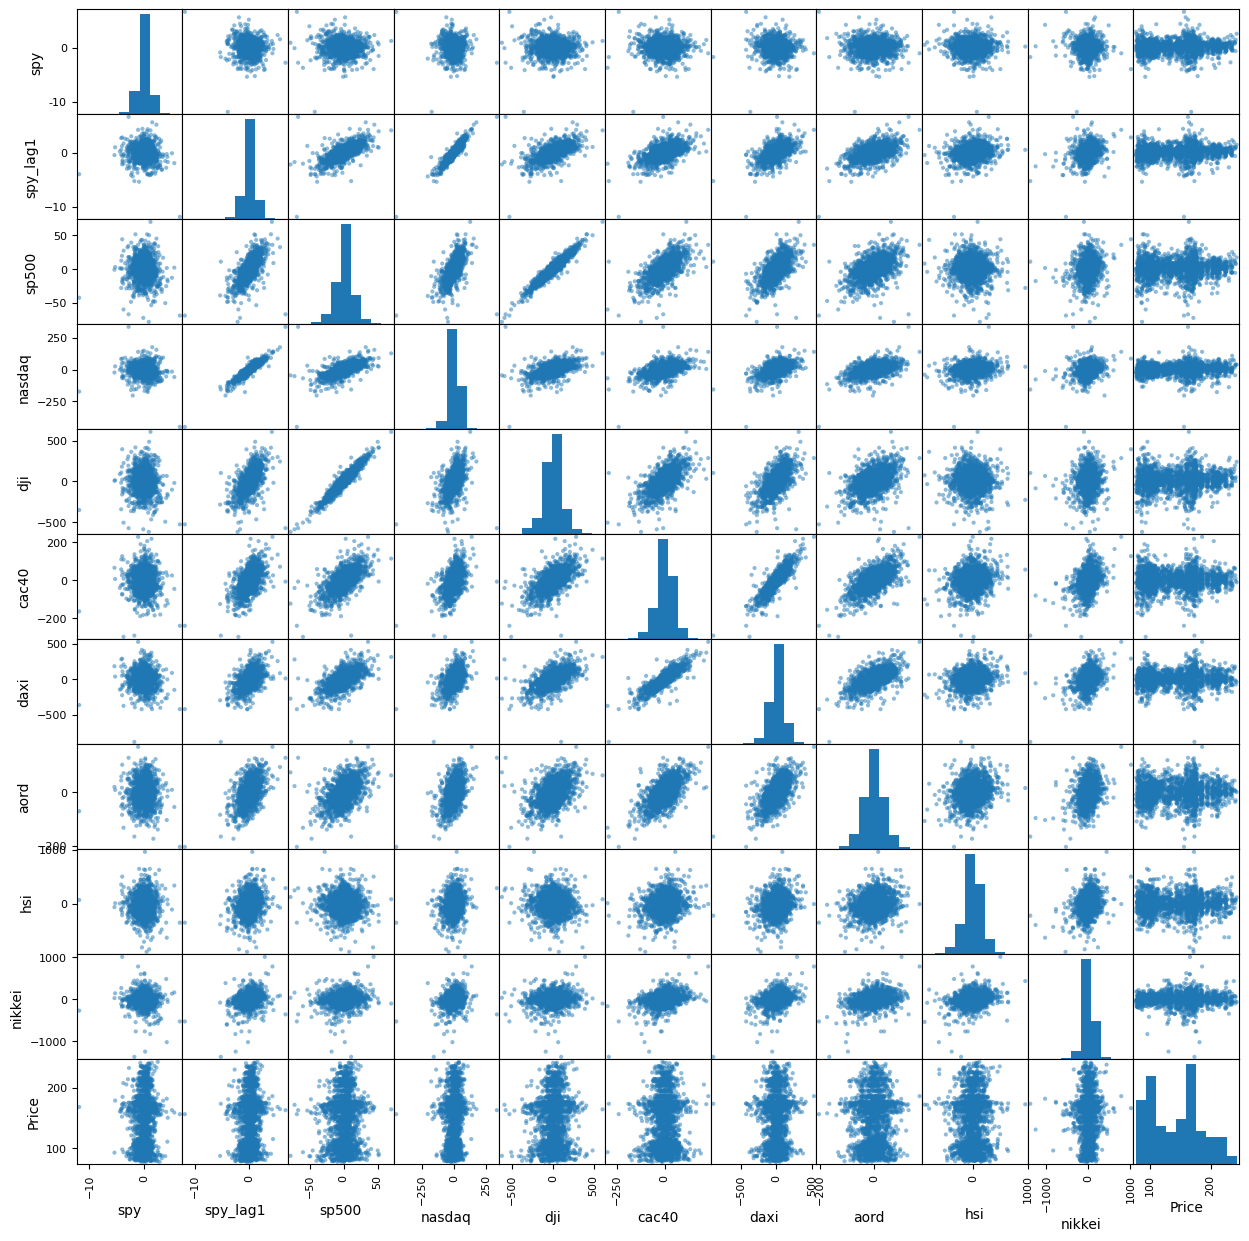

In [321]:
sm = scatter_matrix(Train, figsize=(15, 15))

Upon close inspection, we notice that **sp500, nasdaq, and dji** (the top-left cluster), as well as **cac40 and daxi** (the European market cluster) form tight, narrow, diagonal linear bands. This means that these features are highly correlated with one another. Feeding all of them into a standard OLS regression simultaneously will trigger severe multicollinearity and inflate the standard errors of the coefficients. So, we will select just one representative from each region.

We also note that "Price" (our response variable) is poorly correlated with all the market shifts. Thus, we cannot expect an extraordinarily good prediction.

### Step 4: Find the correlation of each predictor with the response variable (SPY), and fit the training data

In [322]:
corr_array = Train.iloc[:, :-1].corr()['spy']
print(corr_array)

spy         1.000000
spy_lag1   -0.050176
sp500      -0.023505
nasdaq     -0.039793
dji        -0.034829
cac40      -0.044907
daxi       -0.046283
aord        0.003503
hsi        -0.008816
nikkei     -0.032037
Name: spy, dtype: float64


We see that most correlations are small but **negative**, which is explained by a *market reversion* mechanism, even on time scales as short as a single day.

Interestingly, NIKKEI (Japan) displays a positive correlation. Perhaps this is because of the entirely complementary trading hours. Whatever news happens during the day in Japan, is seen early in the morning by US traders as they wake up, and this leads to movements in the same direction.

In [323]:
formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+aord+daxi+nikkei+hsi'
lm = smf.ols(formula=formula, data=Train).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.231
Date:                Thu, 30 Jul 2026   Prob (F-statistic):             0.0178
Time:                        04:33:46   Log-Likelihood:                -3123.3
No. Observations:                2000   AIC:                             6267.
Df Residuals:                    1990   BIC:                             6323.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0875      0.026      3.359      0.001       0.036       0.139
spy_lag1      -0.0844      0.066     -1.281      0.200      -0.214       0.045
sp500          0.0218      0.008      2.695      0.007       0.006       0.038
nasdaq        -0.0005      0.002     -0.267      0.790      -0.004       0.003
dji           -0.0020      0.001     -2.389      0.017      -0.004      -0.000
cac40         -0.0011      0.001     -0.954      0.340      -0.003       0.001
aord           0.0021      0.001      2.366      0.018       0.000       0.004
daxi          -0.0002      0.001     -0.454      0.650      -0.001       0.001
nikkei        -0.0001      0.000     -0.685      0.493      -0.001       0.000
hsi         2.836e-05      0.000      0.176      0.861      -0.000       0.000
==============================================================================
Omnibus:                      507.008   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6107.117
Skew:                          -0.840   Prob(JB):                         0.00
Kurtosis:                      11.394   Cond. No.                         486.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Key takeaways:

- The null hypothesis for the F-test assumes that the slopes corresponding to all the predictors are 0, i.e., none of the predictors are significant. Observe that the p-value for the F-statistic is extremely small, which means we can reject the null hypothesis and conclude that at least one of the predictors is significant enough.
- Based on the p-values for each individual predictor, we can say that spy_lag1, sp500, nikkei, and hsi are the ones that could be statistically significant in their effects on the SPY ETF price. This can be explained as follows:
(a) spy_lag1 is just a one day lag of the daily changes, so we expect some correlation purely based on the mean reversion mechanism, if nothing else. (b) S&P 500, DJI and NASDAQ are all highly correlated since they all belong to the US market. So, choosing any one representative of them is sufficient. (c) The European predictors (CAC40 and DAXI) are not statistically significant, maybe because there is not enough time between their operating hours and the US market's, in order to see tangible effects. (d) Finally, AORD is also lost due to its correlations to the European markets, while NIKKEI and HSI survive thanks to the difference in operating hours, combined with unique market dynamics that are strongly coupled with the American tech industry. 
- The Durbin-Watson statistic has a value that is practically 2, indicating that the noise in the system is essentially an uncorrelated time series.

### Step 5: Make predictions

We now use this trained OLS fit to predict the response variable (Price) for the predictors from both the training and test data sets.

In [324]:
Train['PredictedY'] = lm.predict(Train)
Test['PredictedY'] = lm.predict(Test)

We can check the goodness of the fit by making a scatter plot between the prediction and the actual Price value in the training data.

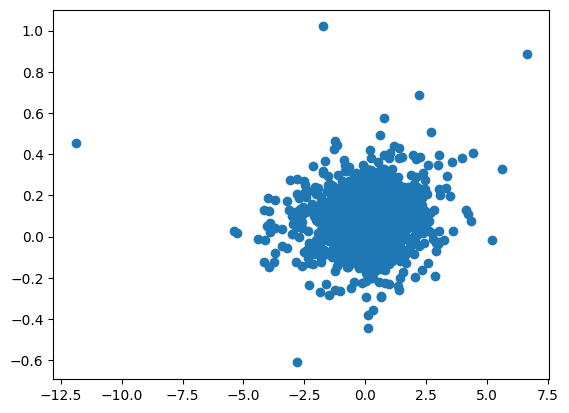

In [325]:
plt.scatter(Train['spy'], Train['PredictedY'])

Clearly, this is not great, but it's also not terrible. We will now quantify it.

### Step 6: Model evaluation - Statistical standard

We can measure the performance of our model using some statistical metrics: *RMSE*, *Adjusted $\text{R}^2$*.

*Note*: Adjusted R-squared is a modified statistical measure that adjusts for the number of predictors in a regression model, penalizing the inclusion of useless variables, and always remaining lower than or equal to standard R-squared. 
Standard R-squared always goes up when you add more input variables, even if those variables are completely random or useless. Adjusted R-squared only goes up if a new variable improves the model more than what you would expect by pure chance.

$$\text{R}^2 = 1- \frac{\text{SS}_{res}}{\text{SS}_{tot}},$$

$$\text{Adjusted R}^2 = 1- \frac{\text{SS}_{res}/(n-p-1)}{\text{SS}_{tot}/(n-1)},$$
where $p$ is the number of *explanatory* variables in the model (excluding the intercept).

In [326]:
# RMSE - Root Mean Squared Error, Adjusted R^2
def adjustedMetric(data, model, model_k, yname):
    data['yhat'] = model.predict(data)
    SST = ((data[yname] - data[yname].mean())**2).sum()
    SSR = ((data['yhat'] - data[yname].mean())**2).sum()
    SSE = ((data[yname] - data['yhat'])**2).sum()
    r2 = SSR/SST
    adjustR2 = 1 - (1-r2)*(data.shape[0] - 1)/(data.shape[0] -model_k -1)
    RMSE = (SSE/(data.shape[0] -model_k -1))**0.5
    return adjustR2, RMSE

In [327]:
def assessTable(test, train, model, model_k, yname):
    r2train, RMSEtrain = adjustedMetric(train, model, model_k, yname)
    r2test, RMSEtest = adjustedMetric(test, model, model_k, yname)
    assessment = pd.DataFrame(index=['R2', 'RMSE'], columns=['Train', 'Test'])
    assessment['Train'] = [r2train, RMSEtrain]
    assessment['Test'] = [r2test, RMSEtest]
    return assessment

In [328]:
assessTable(Test, Train, lm, 9, 'spy')

,Train,Test
R2,0.005512,0.000902
RMSE,1.156268,4.450392


The Adjusted $\text{R}^2$ is very low for both training and testing data sets, implying that there is plenty of unexplained variance. This also suggests *underfitting* of the model to the data, which could be a consequence of either an extremely noisy system or working with ineffective predictors (or both).

## Trading strategy based on the model

We will now use the model that we fit to test a trading strategy. If the price of SPY is predicted to move up, we will long the ETF. If not, we will short it. We begin with the training data set.

We also compare our *signal-based strategy* with a *buy-and-hold strategy*. The latter refers to the passive approach of buying a single share of SPY on day 1 and holding it for the entire period.

In [329]:
Train['Order'] = [1 if sig>0 else -1 for sig in Train['PredictedY']]
Train['Profit'] = Train['spy'] * Train['Order']

Train['Wealth'] = Train['Profit'].cumsum()
print(f"Total profit made in Train: ${Train['Profit'].sum():.2f}")

Total profit made in Train: $173.61


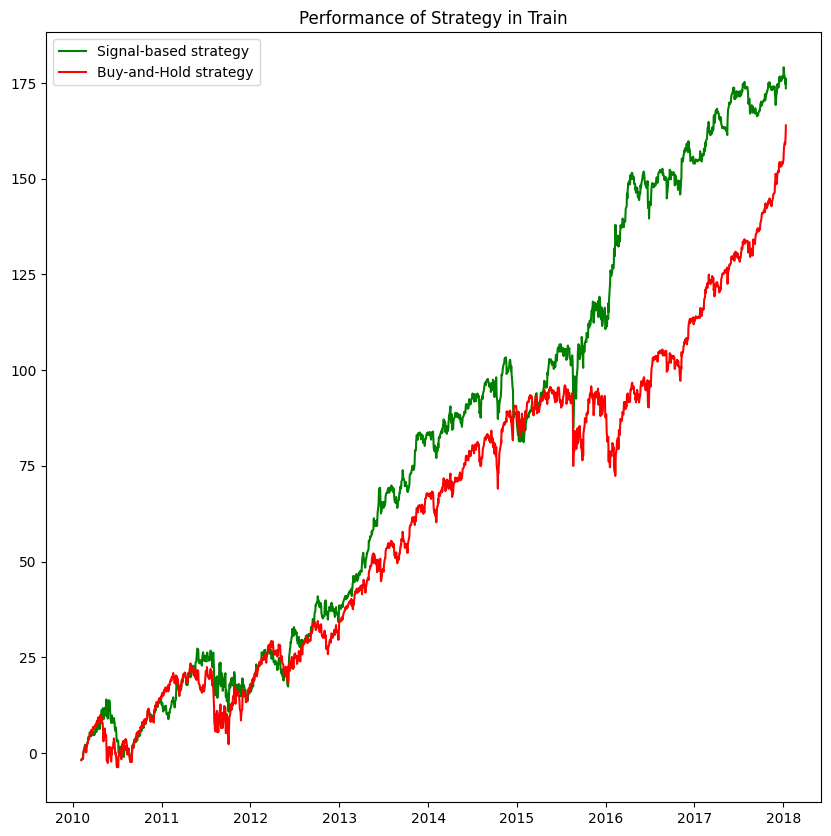

In [330]:
plt.figure(figsize=(10, 10))
plt.title('Performance of Strategy in Train')
plt.plot(Train['Wealth'], color='green', label='Signal-based strategy')
plt.plot(Train['spy'].cumsum(), color='red', label='Buy-and-Hold strategy')
plt.legend()
plt.show()

We can also repeat this with the test data set.

In [331]:
# Test
Test['Order'] = [1 if sig>0 else -1 for sig in Test['PredictedY']]
Test['Profit'] = Test['spy'] * Test['Order']

Test['Wealth'] = Test['Profit'].cumsum()
print(f"Total profit made in Test: ${Test['Profit'].sum():.2f}")

Total profit made in Test: $492.44


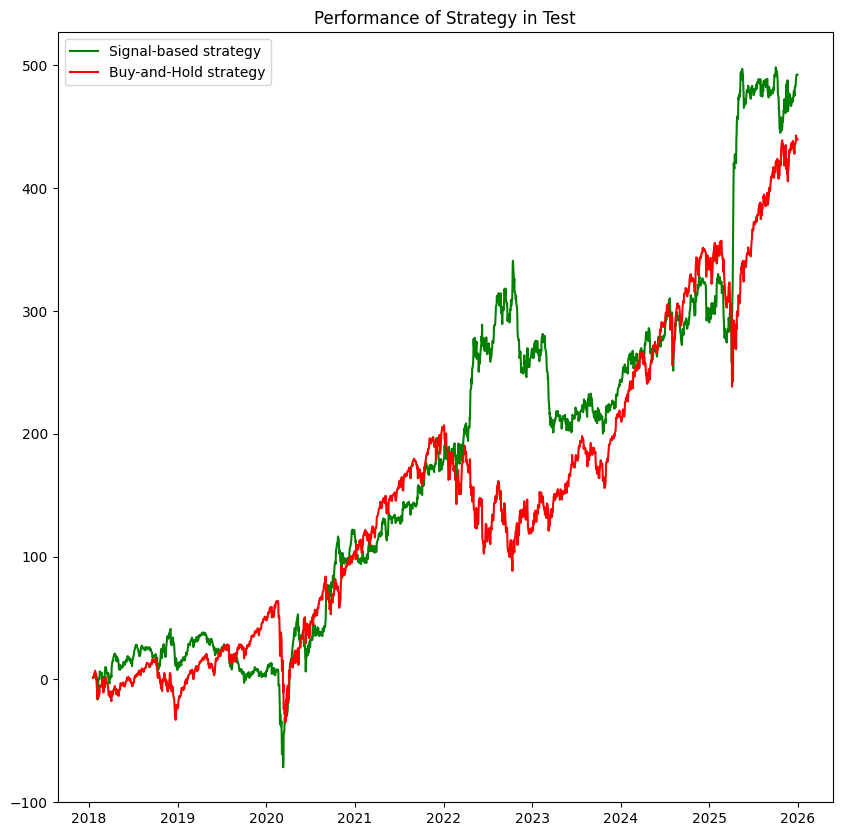

In [332]:
plt.figure(figsize=(10, 10))
plt.title('Performance of Strategy in Test')
plt.plot(Test['Wealth'], color='green', label='Signal-based strategy')
plt.plot(Test['spy'].cumsum(), color='red', label='Buy-and-Hold strategy')
plt.legend()
plt.show()

## Evaluation of model - Practical standard

We now discuss two commonly used methods to evaluate model performance: **Sharpe ratio** and **Maximum Drawdown**.

### Sharpe ratio

This is the mean value of the excess return divided by the standard deviation of the excess return. In other words, it is a measure of whether the strategy's profit was worth the volatility stress that we endured. The annual Sharpe ratio is obtained by multiplying the daily Sharpe ratio by $\sqrt{252}$.

In [333]:
# calculate the final wealth as initial investment + wealth made in the signal-based strategy
Train['Wealth'] = Train['Wealth'] + Train.loc[Train.index[0], 'Price']
Test['Wealth'] = Test['Wealth'] + Test.loc[Test.index[0], 'Price']

In [334]:
# Sharpe Ratio on Train data
Train['Return'] = np.log(Train['Wealth']) - np.log(Train['Wealth'].shift(1))
dailyr = Train['Return'].dropna()

print('Daily Sharpe Ratio is ', dailyr.mean()/dailyr.std(ddof=1))
print('Yearly Sharpe Ratio is ', (252**0.5)*dailyr.mean()/dailyr.std(ddof=1))

Daily Sharpe Ratio is  0.06994399452426739
Yearly Sharpe Ratio is  1.11032649128205


In [335]:
# Sharpe Ratio in Test data
Test['Return'] = np.log(Test['Wealth']) - np.log(Test['Wealth'].shift(1))
dailyr = Test['Return'].dropna()

print('Daily Sharpe Ratio is ', dailyr.mean()/dailyr.std(ddof=1))
print('Yearly Sharpe Ratio is ', (252**0.5)*dailyr.mean()/dailyr.std(ddof=1))

Daily Sharpe Ratio is  0.0476799544595025
Yearly Sharpe Ratio is  0.7568958121363724


An annual Sharpe ratio that is less than 1 indicates a suboptimal strategy, while a Sharpe ratio greater than 2 suggests a very good strategy.

#### *Fun facts*: 
- In calculating the Sharpe ratio, we needed the excess returns of our portfolio. We made two simplifying assumptions here: (a) the risk-free rate is assumed to be 0, and (b) the return of the portfolio was approximated by the log-returns, since $\ln(1+r)\approx r$ for small $r$.
- The denominator of the Sharpe ratio is the standard deviation of the portfolio, which is the total risk. However, if that is replaced by the $\beta$ of the portfolio (i.e., the correlation between the portfolio and the overall market), then we get the **Treynor ratio**.

### Maximum Drawdown

Maximum Drawdown (MDD) measures the largest peak-to-trough drop in the value of your portfolio before a new peak is achieved. It represents the ultimate worst-case scenario a trader would have experienced if they invested at the worst possible moment.

$$MDD = \frac{\text{Peak value} - \text{Trough value}}{\text{Peak value}}.$$

We use the *cummax* function to keep track of the peak values.

In [336]:
# Maximum Drawdown in Train data
Train['Peak'] = Train['Wealth'].cummax()
Train['Drawdown'] = (Train['Peak'] - Train['Wealth'])/Train['Peak']
print('Maximum Drawdown in Train is ', Train['Drawdown'].max())

Maximum Drawdown in Train is  0.1701115091742052


In [337]:
# Maximum Drawdown in Test data
Test['Peak'] = Test['Wealth'].cummax()
Test['Drawdown'] = (Test['Peak'] - Test['Wealth'])/Test['Peak']
print('Maximum Drawdown in Test is ', Test['Drawdown'].max())

Maximum Drawdown in Test is  0.3952594652353119
